In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu


In [50]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## checking the different emg patterns




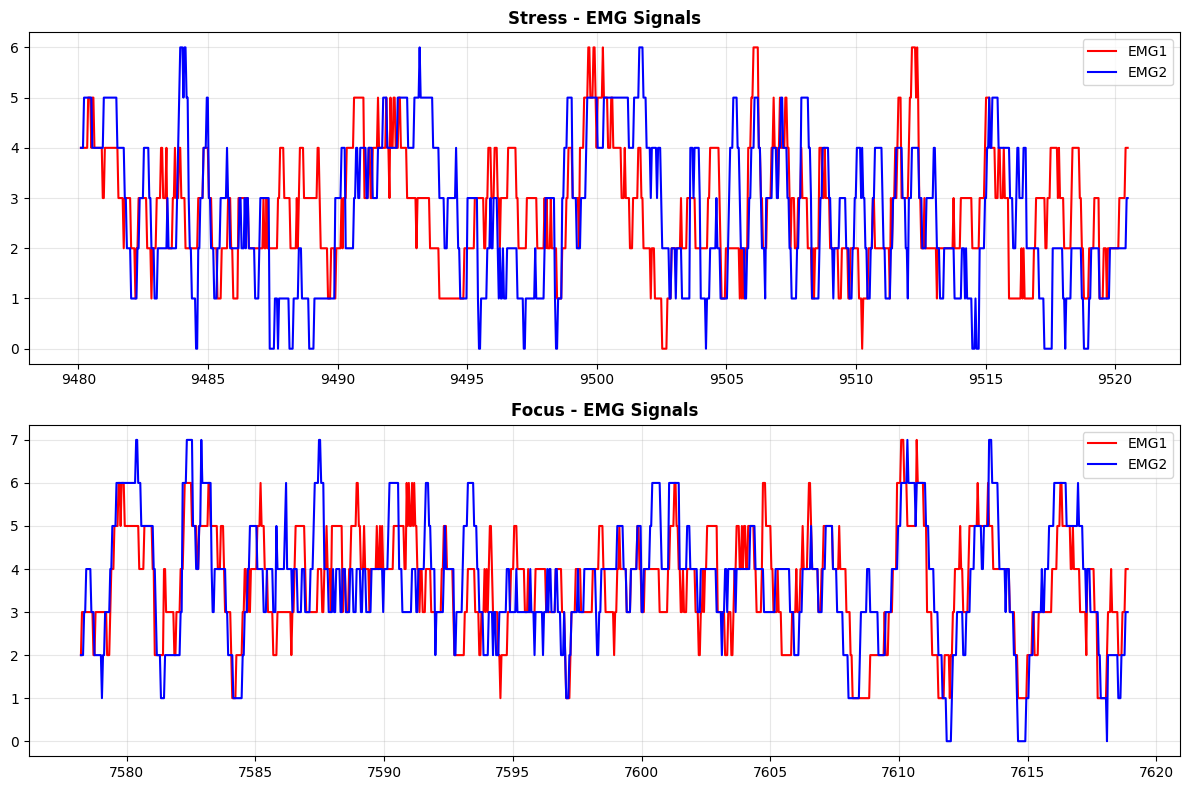

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Stress EMG
axes[0].plot(time_a[:1000], dfa['emg1'].values[:1000], 'r-', label='EMG1', linewidth=1.5)
axes[0].plot(time_a[:1000], dfa['emg2'].values[:1000], 'b-', label='EMG2', linewidth=1.5)
axes[0].set_title('Stress - EMG Signals', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Focus EMG
axes[1].plot(time_b[:1000], dfb['emg1'].values[:1000], 'r-', label='EMG1', linewidth=1.5)
axes[1].plot(time_b[:1000], dfb['emg2'].values[:1000], 'b-', label='EMG2', linewidth=1.5)
axes[1].set_title('Focus - EMG Signals', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Applying 16 4 for all the samples

In [51]:
import os, glob
import numpy as np
import pandas as pd

DATA_DIR = "data/my_raw_data"

# Label mapping from filenames
label_map = {
    "baseline": "relaxed",
    "focus": "focused",
    "distract": "distracted",
    "stress": "stressed"
}

all_cols = ["host_time_s","t_ms","ax1","ay1","az1","gx1","gy1","gz1","yaw1","pitch1","roll1",
            "ax2","ay2","az2","gx2","gy2","gz2","yaw2","pitch2","roll2","emg1","emg2"]

time_cols = ["host_time_s", "t_ms"]
feature_cols = [c for c in all_cols if c not in time_cols]


WINDOW_SIZE = 125
STEP_SIZE = int(WINDOW_SIZE/2)

print(f"Features: {len(feature_cols)}")
print(f"Window size: {WINDOW_SIZE}, Step: {STEP_SIZE}")

Features: 20
Window size: 125, Step: 62


In [52]:
def infer_label_from_filename(fname: str) -> str:
    lower = fname.lower()
    for key, lab in label_map.items():
        if key in lower:
            return lab
    raise ValueError(f"Could not infer label for: {fname}")


In [53]:
X_list = []
y_list = []

all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print("Found files:", [os.path.basename(f) for f in all_files])

for fpath in all_files:
    fname = os.path.basename(fpath)
    print(f"\nProcessing {fname}...")

    df = pd.read_csv(fpath)

    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    label = infer_label_from_filename(fname)

    window_size = WINDOW_SIZE
    step_size = STEP_SIZE
    print(f"  Using window_size={window_size}, step_size={step_size}")

    n_samples = data.shape[0]
    start = 0
    while start + window_size <= n_samples:
        window = data[start:start + window_size]
        X_list.append(window)
        y_list.append(label)
        start += step_size

X = np.stack(X_list, axis=0)
y = np.array(y_list)

print("\n✅ Dataset created!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", np.unique(y, return_counts=True))


Found files: ['adi1_7_5min_distract.csv', 'emmanuel1_7_5min_baseline.csv', 'jun_5_7min_distract.csv', 'louis1_7_5min_distract.csv', 'jun_5_7min_stress.csv', 'louis1_7_5min_baseline.csv', 'jun_5_7min_baseline.csv', 'adi1_7_5min_stress.csv', 'emmanuel1_7_5min_distract.csv', 'louis1_7_5min_stress.csv', 'jun_5_7min_focus.csv', 'adi1_7_5min_baseline.csv', 'louis1_7_5min_focus.csv', 'emmanuel1_7_5min_focus.csv', 'emmanuel1_7_5min_stress.csv', 'adi1_7_5min_focus.csv']

Processing adi1_7_5min_distract.csv...
  Using window_size=125, step_size=62

Processing emmanuel1_7_5min_baseline.csv...
  Using window_size=125, step_size=62

Processing jun_5_7min_distract.csv...
  Using window_size=125, step_size=62

Processing louis1_7_5min_distract.csv...
  Using window_size=125, step_size=62

Processing jun_5_7min_stress.csv...
  Using window_size=125, step_size=62

Processing louis1_7_5min_baseline.csv...
  Using window_size=125, step_size=62

Processing jun_5_7min_baseline.csv...
  Using window_size=12

In [54]:
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y)
print("Label mapping:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

y_cat = F.one_hot(torch.tensor(y_int)).numpy()

# Train val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_int, test_size=0.2, random_state=42, stratify=y_int
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")

Label mapping: {np.str_('distracted'): 0, np.str_('focused'): 1, np.str_('relaxed'): 2, np.str_('stressed'): 3}

Train: 2314 samples
Val:   579 samples


In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_torch = torch.FloatTensor(X_train).transpose(1, 2)
# X_train_torch = torch.FloatTensor(X_train)

X_val_torch   = torch.FloatTensor(X_val).transpose(1, 2)
# X_val_torch   = torch.FloatTensor(X_val)

y_train_torch = torch.LongTensor(y_train)
y_val_torch   = torch.LongTensor(y_val)

print(f"X_train_torch shape: {X_train_torch.shape}")
print(f"X_val_torch shape:   {X_val_torch.shape}")

BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_torch, y_train_torch)
val_dataset   = TensorDataset(X_val_torch,   y_val_torch)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

for batch_X, batch_y in train_loader:
    print(f"FIRST BATCH shape: {batch_X.shape}")
    break

Using device: cpu
X_train_torch shape: torch.Size([2314, 20, 125])
X_val_torch shape:   torch.Size([579, 20, 125])
FIRST BATCH shape: torch.Size([32, 20, 125])


In [ ]:
# Train REGULARIZED version
# class EmotionCNN_Reg(nn.Module):
#     def __init__(self, input_channels=20, num_classes=4):
#         super().__init__()
#         self.conv1 = nn.Conv1d(input_channels, 16, kernel_size=3, padding=1)
#         self.bn1   = nn.BatchNorm1d(16)
#         self.pool1 = nn.MaxPool1d(2)

#         self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
#         self.bn2   = nn.BatchNorm1d(32)
#         self.pool2 = nn.MaxPool1d(2)

#         self.fc1       = nn.Linear(32 * 4, 64)
#         self.dropout1  = nn.Dropout(0.3)
#         self.fc2       = nn.Linear(64, 32)
#         self.dropout2  = nn.Dropout(0.5)
#         self.fc3       = nn.Linear(32, num_classes)

#     def forward(self, x):
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = self.pool1(x)
#         x = F.dropout(x, 0.2)

#         x = F.relu(self.bn2(self.conv2(x)))
#         x = self.pool2(x)

#         x = x.view(x.size(0), -1)
#         x = F.relu(self.fc1(x))
#         x = self.dropout1(x)
#         x = F.relu(self.fc2(x))
#         x = self.dropout2(x)
#         x = self.fc3(x)
#         return x

# # Retrain with regularization
# model_reg = EmotionCNN_Reg(input_channels=X_train_torch.shape[1],
#                            num_classes=4).to(device)
# optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-3)
# criterion = nn.CrossEntropyLoss()

# print("🛡️ Training regularized model...")
# print("Input channels:", X_train_torch.shape[1])
# print("Total params:", sum(p.numel() for p in model_reg.parameters()))


🛡️ Training regularized model...
Input channels: 20
Total params: 13108


In [56]:
# Train REGULARIZED version
class EmotionCNN_Reg(nn.Module):
    def __init__(self, input_channels=20, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)

        self.fc1       = nn.Linear(32*31 , 64)
        self.dropout1  = nn.Dropout(0.3)
        self.fc2       = nn.Linear(64, 32)
        self.dropout2  = nn.Dropout(0.5)
        self.fc3       = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.dropout(x, 0.2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Retrain with regularization
# model_reg = EmotionCNN_Reg(input_channels=X_train_torch.shape[1],
#                            num_classes=4).to(device)
# optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-3)
# criterion = nn.CrossEntropyLoss()

print("🛡️ Training regularized model...")
print("Input channels:", X_train_torch.shape[1])
print("Total params:", sum(p.numel() for p in model_reg.parameters()))



X_train_torch.shape[1]

🛡️ Training regularized model...
Input channels: 20
Total params: 68404


20

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CostSensitiveLoss(nn.Module):
    def __init__(self, cost_matrix):
        super(CostSensitiveLoss, self).__init__()
        # Ensure the matrix is a PyTorch tensor on the correct device (CPU/GPU)
        self.cost_matrix = torch.tensor(cost_matrix, dtype=torch.float32)

    def forward(self, logits, targets):
        # 1. Convert the raw model outputs (logits) into percentages (0.0 to 1.0)
        probs = F.softmax(logits, dim=1)
        
        # 2. Match the penalty matrix device to the targets device
        self.cost_matrix = self.cost_matrix.to(targets.device)
        
        # 3. Pull the specific penalty rows for the true classes in this batch
        # If the target is 3 (Relaxed), it pulls the [1.0, 10.0, 1.0, 0.0] row
        batch_costs = self.cost_matrix[targets]
        
        # 4. Multiply the model's predicted probabilities by the penalties
        # If it predicted "Stressed" (column 1) with 90% confidence, 
        # the loss explodes: 0.90 * 10.0 penalty = Huge Loss!
        expected_costs = torch.sum(batch_costs * probs, dim=1)
        
        # 5. Return the average loss for the batch
        return torch.mean(expected_costs)

In [ ]:
# Define your Risk Averse penalties
penalty_grid = [
    [0.0, 5.0, 1.0, 1.0],  # True: Distracted
    [1.0, 0.0, 1.0, 1.0],  # True: Focused
    [1.0, 2.0, 0.0, 1.0],  # True: Relaxed
    [1.0, 10.0, 1.0, 0.0]  # True: Stressed
]

In [74]:
# Use REGULARIZED model
model_reg = EmotionCNN_Reg(input_channels=X_train_torch.shape[1],
                           num_classes=4).to(device)
# criterion = nn.CrossEntropyLoss()
criterion = CostSensitiveLoss(cost_matrix=penalty_grid)
optimizer = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 500
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

print("🛡️ Training REGULARIZED model...")
print(f"Input channels: {len(feature_cols)}")
print(f"Total params: {sum(p.numel() for p in model_reg.parameters()):,}")

for epoch in range(EPOCHS):
    # Training
    model_reg.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model_reg(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    # Validation
    model_reg.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model_reg(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()

    # Metrics
    train_loss = running_loss / len(train_loader)
    val_loss_epoch = val_loss / len(val_loader)
    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss_epoch)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss_epoch)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_reg.state_dict(), "best_emotion_cnn_reg.pth")

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(
            f"Epoch {epoch+1}/{EPOCHS}: "
            f"Train: {train_loss:.4f} ({train_acc:.1f}%) | "
            f"Val: {val_loss_epoch:.4f} ({val_acc:.1f}%)"
        )

print(f"\n✅ Best val accuracy: {best_val_acc:.1f}%")
print("💾 Saved: best_emotion_cnn_reg.pth")


🛡️ Training REGULARIZED model...
Input channels: 20
Total params: 68,404
Epoch 1/500: Train: 3.8638 (25.4%) | Val: 3.0085 (30.9%)
Epoch 11/500: Train: 1.1910 (44.8%) | Val: 1.0821 (43.7%)
Epoch 21/500: Train: 0.8568 (48.7%) | Val: 0.8842 (48.7%)
Epoch 31/500: Train: 0.8366 (49.7%) | Val: 0.8091 (50.9%)
Epoch 41/500: Train: 0.7345 (52.2%) | Val: 0.7748 (50.8%)
Epoch 51/500: Train: 0.6717 (53.9%) | Val: 0.8370 (52.2%)
Epoch 61/500: Train: 0.6675 (55.6%) | Val: 0.7694 (53.0%)
Epoch 71/500: Train: 0.6323 (56.4%) | Val: 0.7612 (54.6%)
Epoch 81/500: Train: 0.5472 (59.2%) | Val: 0.7231 (54.6%)
Epoch 91/500: Train: 0.5632 (58.9%) | Val: 0.7103 (55.1%)
Epoch 101/500: Train: 0.5840 (58.4%) | Val: 0.7433 (54.2%)
Epoch 111/500: Train: 0.6104 (57.8%) | Val: 0.7372 (54.7%)
Epoch 121/500: Train: 0.5575 (59.3%) | Val: 0.6860 (54.4%)
Epoch 131/500: Train: 0.5834 (57.8%) | Val: 0.6842 (54.9%)
Epoch 141/500: Train: 0.5549 (58.3%) | Val: 0.7079 (55.6%)
Epoch 151/500: Train: 0.5656 (58.7%) | Val: 0.7289 (5

In [75]:
# Load BEST regularized model
model_reg.load_state_dict(torch.load('best_emotion_cnn_reg.pth'))
model_reg.eval()

# Get predictions
all_preds_reg = []
all_labels_reg = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        outputs = model_reg(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_preds_reg.extend(predicted.cpu().numpy())
        all_labels_reg.extend(batch_y.cpu().numpy())

print("📊 REGULARIZED MODEL RESULTS:")
print(classification_report(all_labels_reg, all_preds_reg,
                          target_names=label_encoder.classes_))


📊 REGULARIZED MODEL RESULTS:
              precision    recall  f1-score   support

  distracted       0.61      0.52      0.56       145
     focused       0.48      0.97      0.64       145
     relaxed       0.00      0.00      0.00       144
    stressed       0.60      0.67      0.63       145

    accuracy                           0.54       579
   macro avg       0.42      0.54      0.46       579
weighted avg       0.42      0.54      0.46       579



/Users/bossbaby07/Documents/Projects/GIT/EmoRec-Karios/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/bossbaby07/Documents/Projects/GIT/EmoRec-Karios/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/bossbaby07/Documents/Projects/GIT/EmoRec-Karios/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

<Figure size 1000x800 with 0 Axes>

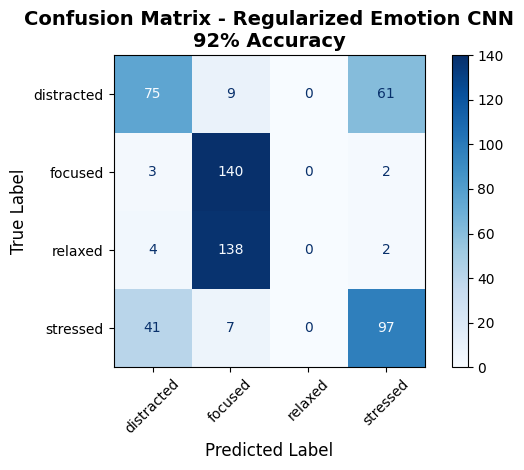

Confusion Matrix (True ↓ | Predicted →):
[[ 75   9   0  61]
 [  3 140   0   2]
 [  4 138   0   2]
 [ 41   7   0  97]]

Class order: ['distracted' 'focused' 'relaxed' 'stressed']


In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels_reg, all_preds_reg)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Confusion Matrix - Regularized Emotion CNN\n92% Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("Confusion Matrix (True ↓ | Predicted →):")
print(cm)
print(f"\nClass order: {label_encoder.classes_}")


In [47]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    # Normalize features (same as training)
    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

test_file = "EmoRecData/louis_stressed.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

# Fixed output display
filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n📊 PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f"📋 TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on louis_stressed.csv:
🎯 11 windows predicted
Most common counts: [0 7 0 4]

First 10 predictions:
   1: stressed
   2: focused
   3: stressed
   4: focused
   5: focused
   6: focused
   7: focused
   8: focused
   9: focused
  10: stressed

📊 PREDICTION DISTRIBUTION:
  focused   : 7/11 (64%)
  stressed  : 4/11 (36%)

🎯 TOP PREDICTION: focused (64%)
📋 TRUE LABEL:     stressed


In [48]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    # Normalize features (same as training)
    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

test_file = "EmoRecData/adi_focused.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

# Fixed output display
filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n📊 PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f"📋 TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on adi_focused.csv:
🎯 5 windows predicted
Most common counts: [1 0 4 0]

First 10 predictions:
   1: relaxed
   2: relaxed
   3: relaxed
   4: relaxed
   5: distracted

📊 PREDICTION DISTRIBUTION:
  distracted: 1/5 (20%)
  relaxed   : 4/5 (80%)

🎯 TOP PREDICTION: relaxed (80%)
📋 TRUE LABEL:     focused


In [49]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    # Normalize features (same as training)
    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

test_file = "EmoRecData/louis_focused.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n📊 PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f"📋 TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on louis_focused.csv:
🎯 11 windows predicted
Most common counts: [2 4 5 0]

First 10 predictions:
   1: focused
   2: focused
   3: focused
   4: distracted
   5: relaxed
   6: focused
   7: relaxed
   8: relaxed
   9: relaxed
  10: distracted

📊 PREDICTION DISTRIBUTION:
  distracted: 2/11 (18%)
  focused   : 4/11 (36%)
  relaxed   : 5/11 (45%)

🎯 TOP PREDICTION: relaxed (45%)
📋 TRUE LABEL:     focused


In [58]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file - handles object dtype conversion."""
    df = pd.read_csv(fpath)

    # Convert object columns to float (handles your mixed dtypes)
    for col in feature_cols:
        if col in df.columns:
            # Coerce to numeric, replace errors with NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')

    for col in feature_cols:
        if col in df.columns and df[col].notna().sum() > 0:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values  # Drop rows with any NaN

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        print(f"❌ No valid windows created from {os.path.basename(fpath)}")
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

# Test both new files
test_files = [
    "/content/drive/MyDrive/EmoRecData/stress_w_20sec_baseline.csv",
    "/content/drive/MyDrive/EmoRecData/focus_test.csv"
]

for test_file in test_files:
    labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

    if labels_reg is not None:
        filename = os.path.basename(test_file)
        print(f"\n🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
        print(f"🎯 {len(labels_reg)} windows predicted")

        print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

        print("\nFirst 10 predictions:")
        for i, pred in enumerate(labels_reg[:10]):
            print(f"  {i+1:2d}: {pred}")

        print("\n📊 PREDICTION DISTRIBUTION:")
        unique, counts = np.unique(labels_reg, return_counts=True)
        total_windows = len(labels_reg)
        for label, count in zip(unique, counts):
            pct = count / total_windows * 100
            print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

        top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
        top_class = label_encoder.classes_[top_class_idx]
        top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)

        true_label = infer_label_from_filename(filename)
        print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
        print(f"📋 FILENAME SUGGESTS: {true_label}")
        print("-" * 60)
    else:
        print(f"❌ Failed to process {os.path.basename(test_file)}")



🛡️ REGULARIZED MODEL (92% val acc) on stress_w_20sec_baseline.csv:
🎯 60 windows predicted
Most common counts: [11  9 16 24]

First 10 predictions:
   1: stressed
   2: stressed
   3: stressed
   4: stressed
   5: relaxed
   6: stressed
   7: stressed
   8: stressed
   9: relaxed
  10: stressed

📊 PREDICTION DISTRIBUTION:
  distracted: 11/60 (18%)
  focused   : 9/60 (15%)
  relaxed   : 16/60 (27%)
  stressed  : 24/60 (40%)

🎯 TOP PREDICTION: stressed (40%)
📋 FILENAME SUGGESTS: relaxed
------------------------------------------------------------

🛡️ REGULARIZED MODEL (92% val acc) on focus_test.csv:
🎯 76 windows predicted
Most common counts: [ 5  7 42 22]

First 10 predictions:
   1: focused
   2: relaxed
   3: relaxed
   4: distracted
   5: stressed
   6: relaxed
   7: focused
   8: relaxed
   9: distracted
  10: focused

📊 PREDICTION DISTRIBUTION:
  distracted: 5/76 (7%)
  focused   : 7/76 (9%)
  relaxed   : 42/76 (55%)
  stressed  : 22/76 (29%)

🎯 TOP PREDICTION: relaxed (55%)
📋 FILE

In [59]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

test_file = "/content/drive/MyDrive/EmoRecData/adi_stressed.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n📊 PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f"📋 TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on adi_stressed.csv:
🎯 145 windows predicted
Most common counts: [12 29 47 57]

First 10 predictions:
   1: distracted
   2: distracted
   3: focused
   4: distracted
   5: distracted
   6: stressed
   7: stressed
   8: stressed
   9: stressed
  10: stressed

📊 PREDICTION DISTRIBUTION:
  distracted: 12/145 (8%)
  focused   : 29/145 (20%)
  relaxed   : 47/145 (32%)
  stressed  : 57/145 (39%)

🎯 TOP PREDICTION: stressed (39%)
📋 TRUE LABEL:     stressed
